In [5]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
import streamlit as st

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor

In [6]:
df = pd.read_csv("india_housing_prices.csv")

In [7]:
df

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,249996,Gujarat,Ahmedabad,Locality_187,Independent House,5,1995,274.75,0.14,1995,...,30,8,6,Low,No,No,"Playground, Garden, Gym, Clubhouse, Pool",East,Broker,Under_Construction
249996,249997,Tamil Nadu,Chennai,Locality_348,Apartment,1,2293,13.40,0.01,2013,...,12,8,10,Low,No,No,Playground,South,Broker,Ready_to_Move
249997,249998,Telangana,Warangal,Locality_225,Villa,4,2910,236.94,0.08,2003,...,22,10,4,High,Yes,Yes,Playground,South,Builder,Under_Construction
249998,249999,Odisha,Cuttack,Locality_138,Villa,1,1149,141.66,0.12,2007,...,18,3,7,Low,Yes,Yes,"Playground, Gym, Pool",South,Owner,Ready_to_Move


In [8]:
print(df.head())

   ID        State      City      Locality      Property_Type  BHK  \
0   1   Tamil Nadu   Chennai   Locality_84          Apartment    1   
1   2  Maharashtra      Pune  Locality_490  Independent House    3   
2   3       Punjab  Ludhiana  Locality_167          Apartment    2   
3   4    Rajasthan   Jodhpur  Locality_393  Independent House    2   
4   5    Rajasthan    Jaipur  Locality_466              Villa    4   

   Size_in_SqFt  Price_in_Lakhs  Price_per_SqFt  Year_Built  ...  \
0          4740          489.76            0.10        1990  ...   
1          2364          195.52            0.08        2008  ...   
2          3642          183.79            0.05        1997  ...   
3          2741          300.29            0.11        1991  ...   
4          4823          182.90            0.04        2002  ...   

  Age_of_Property  Nearby_Schools  Nearby_Hospitals  \
0              35              10                 3   
1              17               8                 1   
2    

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [12]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [13]:
df.fillna(df.mode().iloc[0], inplace=True)

# Creation of age of property

In [14]:
current_year = 2026

df["Age_of_Property"] = current_year - df["Year_Built"]

# Creation of future price(Using 8% annual growth)

In [15]:
growth_rate = 0.08

df["Future_Price_5Y"] = (
    df["Price_in_Lakhs"] * ((1 + growth_rate) ** 5)
)

# Creation of Good Investment (Classification Target)

In [16]:
median_price_sqft = df["Price_per_SqFt"].median()

df["Good_Investment"] = (
    df["Price_per_SqFt"] <= median_price_sqft
).astype(int)

# EDA

## Price Distribution

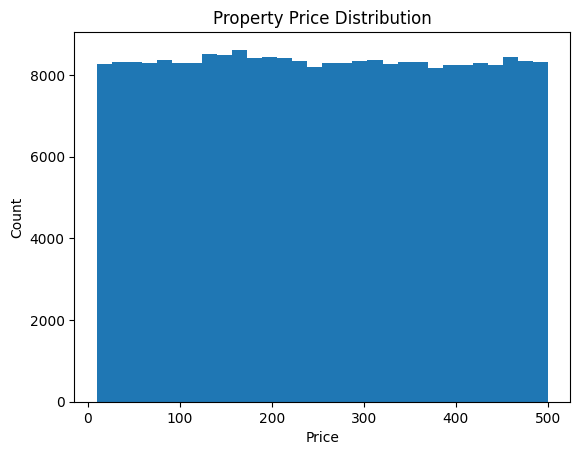

In [17]:
import matplotlib.pyplot as plt

plt.hist(df["Price_in_Lakhs"], bins=30)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Property Price Distribution")
plt.show()

## Correlation heatmap

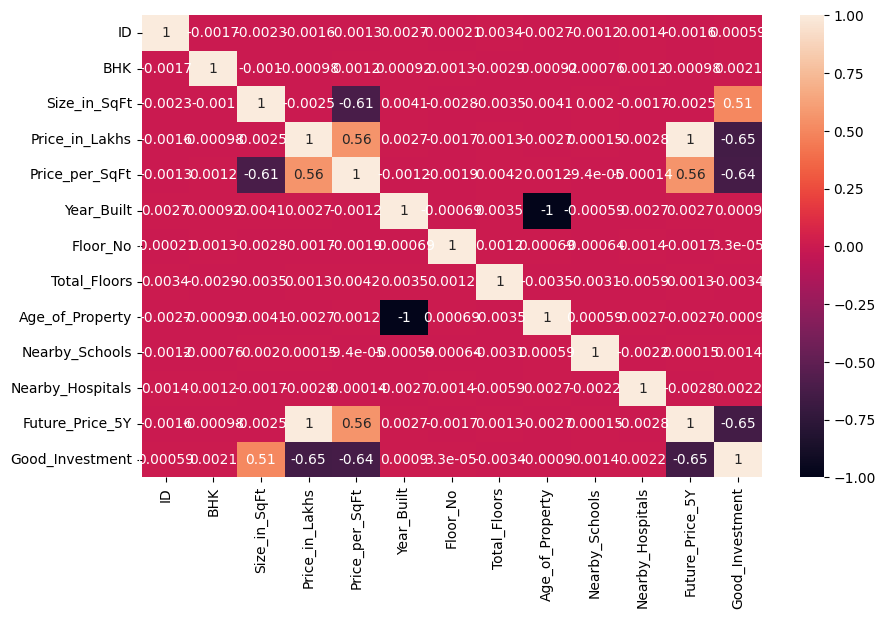

In [18]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

## price vs size

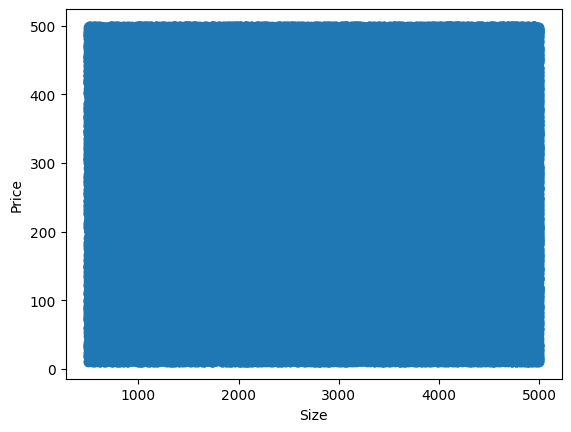

In [19]:
plt.scatter(df["Size_in_SqFt"], df["Price_in_Lakhs"])
plt.xlabel("Size")
plt.ylabel("Price")
plt.show()

## Encoding

In [20]:
df = pd.get_dummies(df, drop_first=True)

# Classification Model

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df.drop(["Good_Investment", "Future_Price_5Y"], axis=1)
y = df["Good_Investment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

clf = RandomForestClassifier()

clf.fit(X_train, y_train)

pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 1.0


# Regression Model

In [22]:
import pickle
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor

drop_cols = ["ID", "Locality", "Amenities"]

df_model = df.drop(columns=drop_cols, errors="ignore")

df_encoded = pd.get_dummies(df_model, drop_first=True)

X = df_encoded.drop(["Good_Investment", "Future_Price_5Y"], axis=1)

y_class = df_encoded["Good_Investment"]
y_reg = df_encoded["Future_Price_5Y"]

clf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

reg = RandomForestRegressor(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

clf.fit(X, y_class)
reg.fit(X, y_reg)

pickle.dump(clf, open("classification_model.pkl", "wb"))
pickle.dump(reg, open("regression_model.pkl", "wb"))

pickle.dump(X.columns.tolist(), open("feature_columns.pkl", "wb"))

print("Models and feature columns saved successfully")

Models and feature columns saved successfully


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

y_reg = df["Future_Price_5Y"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

reg = RandomForestRegressor()

reg.fit(X_train, y_train)

pred = reg.predict(X_test)

print("R2 Score:", r2_score(y_test, pred))

R2 Score: 0.9999999997616461


## Streamlit

In [27]:
%%writefile Real_Estate_app.py

import streamlit as st
import pandas as pd
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

st.set_page_config(page_title="Real Estate Investment Advisor", layout="wide")

st.title("🏠 Real Estate Investment Advisor")
st.write("Predict Good Investment and Future Property Price")

# -------------------------------
# LOAD DATA
# -------------------------------
@st.cache_data
def load_data():
    df = pd.read_csv("india_housing_prices.csv")
    df = df.drop_duplicates()
    df.columns = df.columns.str.strip()

    for col in df.select_dtypes(include="number").columns:
        df[col] = df[col].fillna(df[col].median())

    for col in df.select_dtypes(include="object").columns:
        df[col] = df[col].fillna(df[col].mode()[0])

    df["Age_of_Property"] = 2026 - df["Year_Built"]

    median_price_sqft = df["Price_per_SqFt"].median()
    df["Good_Investment"] = (df["Price_per_SqFt"] <= median_price_sqft).astype(int)

    df["Future_Price_5Y"] = df["Price_in_Lakhs"] * ((1 + 0.08) ** 5)

    return df

df = load_data()

# -------------------------------
# ENCODING FOR FEATURE COLUMNS
# -------------------------------
drop_cols = ["ID"]
df_model = df.drop(columns=drop_cols, errors="ignore")

df_encoded = pd.get_dummies(df_model, drop_first=True)

X = df_encoded.drop(
    ["Good_Investment", "Future_Price_5Y"],
    axis=1
)

feature_columns = pickle.load(open("feature_columns.pkl", "rb"))
# -------------------------------
# LOAD SAVED MODELS
# -------------------------------
@st.cache_resource
def load_models():
    clf = pickle.load(open("classification_model.pkl", "rb"))
    reg = pickle.load(open("regression_model.pkl", "rb"))
    return clf, reg

clf, reg = load_models()

st.success("Models loaded successfully!")

# -------------------------------
# DATA PREVIEW
# -------------------------------
st.subheader("Dataset Preview")
st.dataframe(df.head())

# -------------------------------
# EDA
# -------------------------------
st.subheader("EDA Visualizations")

chart = st.selectbox(
    "Select Chart",
    [
        "Price Distribution",
        "Size vs Price",
        "Average Price by City",
        "BHK Distribution",
        "Correlation Heatmap"
    ]
)

if chart == "Price Distribution":
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.histplot(df["Price_in_Lakhs"], kde=True, ax=ax)
    ax.set_title("Property Price Distribution")
    st.pyplot(fig)

elif chart == "Size vs Price":
    fig, ax = plt.subplots(figsize=(8, 5))
    sample_chart = df.sample(n=min(5000, len(df)), random_state=42)
    sns.scatterplot(
        x="Size_in_SqFt",
        y="Price_in_Lakhs",
        data=sample_chart,
        ax=ax
    )
    ax.set_title("Size vs Price")
    st.pyplot(fig)

elif chart == "Average Price by City":
    city_price = (
        df.groupby("City")["Price_in_Lakhs"]
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    city_price.plot(kind="bar", ax=ax)
    ax.set_title("Top 10 Cities by Average Property Price")
    ax.set_ylabel("Average Price in Lakhs")
    st.pyplot(fig)

elif chart == "BHK Distribution":
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.countplot(x="BHK", data=df, ax=ax)
    ax.set_title("BHK Distribution")
    st.pyplot(fig)

elif chart == "Correlation Heatmap":
    numeric_df = df.select_dtypes(include="number")
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.heatmap(numeric_df.corr(), cmap="coolwarm", ax=ax)
    ax.set_title("Correlation Heatmap")
    st.pyplot(fig)

# -------------------------------
# INPUT FORM
# -------------------------------
st.header("Property Prediction")

col1, col2 = st.columns(2)

with col1:
    state = st.selectbox("State", sorted(df["State"].unique()))
    city = st.selectbox("City", sorted(df[df["State"] == state]["City"].unique()))
    current_price = st.number_input("Current Price in Lakhs", min_value=1.0, value=50.0)
    area = st.number_input("Size in SqFt", min_value=100, value=1000)
    bhk = st.number_input("BHK", min_value=1, value=2)

with col2:
    price_sqft = st.number_input(
        "Price per SqFt",
        min_value=0.0,
        value=0.10,
        step=0.01,
        format="%.2f"
    )

    property_type = st.selectbox("Property Type", sorted(df["Property_Type"].unique()))
    furnished_status = st.selectbox("Furnished Status", sorted(df["Furnished_Status"].unique()))
    age = st.number_input("Age of Property", min_value=0, value=5)
    floor_no = st.number_input("Floor Number", min_value=0, value=1)
    total_floors = st.number_input("Total Floors", min_value=1, value=5)

# -------------------------------
# PREDICTION
# -------------------------------
if st.button("Predict"):
    input_data = {col: 0 for col in feature_columns}

    if "Price_in_Lakhs" in input_data:
        input_data["Price_in_Lakhs"] = current_price

    if "Size_in_SqFt" in input_data:
        input_data["Size_in_SqFt"] = area

    if "BHK" in input_data:
        input_data["BHK"] = bhk

    if "Price_per_SqFt" in input_data:
        input_data["Price_per_SqFt"] = price_sqft

    if "Age_of_Property" in input_data:
        input_data["Age_of_Property"] = age

    if "Floor_No" in input_data:
        input_data["Floor_No"] = floor_no

    if "Total_Floors" in input_data:
        input_data["Total_Floors"] = total_floors

    state_col = f"State_{state}"
    if state_col in input_data:
        input_data[state_col] = 1

    city_col = f"City_{city}"
    if city_col in input_data:
        input_data[city_col] = 1

    property_col = f"Property_Type_{property_type}"
    if property_col in input_data:
        input_data[property_col] = 1

    furnished_col = f"Furnished_Status_{furnished_status}"
    if furnished_col in input_data:
        input_data[furnished_col] = 1

    input_df = pd.DataFrame([input_data])
    input_df = input_df[feature_columns]

    investment_pred = clf.predict(input_df)[0]
    future_price = reg.predict(input_df)[0]

    st.subheader("Prediction Result")

    if investment_pred == 1:
        st.success("✅ Good Investment")
    else:
        st.error("❌ Not a Good Investment")

    st.info(f"Estimated Price After 5 Years: ₹ {future_price:,.2f} Lakhs")

st.markdown("---")
st.write("Real Estate Investment Advisor Project")

Overwriting Real_Estate_app.py


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Features
X = df_encoded.drop(["Good_Investment"], axis=1)

# Target
y = df_encoded["Good_Investment"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Train Model
clf = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

clf.fit(X_train, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [26]:
from sklearn.metrics import accuracy_score, classification_report

pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     24332
           1       1.00      1.00      1.00     25668

    accuracy                           1.00     50000
   macro avg       1.00      1.00      1.00     50000
weighted avg       1.00      1.00      1.00     50000

